In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage.transform import resize
from tqdm import tqdm
from scipy.ndimage import gaussian_filter1d
import warnings
from scipy import stats  
import alphashape
import cmcrameri.cm as cmc
from scipy.ndimage import uniform_filter
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull

#ignore warnings
warnings.filterwarnings("ignore")

In [ ]:
#Import data
Cult_Embryo_data = pd.read_excel("S3_Data.xlsx")

In [ ]:
# Force both Left and Right sides of the embryo to be positive
Cult_Embryo_data['Scaled_Rel_LR_position_positive'] = abs(Cult_Embryo_data['Scaled_Rel_LR_position'].copy())

# Create subsets for left and right sides of the embryo
# this is for plotting purposes to eliminate issues of edge effects at the midline
sub_data_comb1 = Cult_Embryo_data[Cult_Embryo_data['Relative_AP_position'] > -0.6]
sub_data_comb2 = Cult_Embryo_data[Cult_Embryo_data['Relative_AP_position'] > -0.6]
sub_data_comb2['Scaled_Rel_LR_position_positive'] *= -1 # Flip the LR position for the right side

# Combine two with positive and negative LR position
sub_data_comb = pd.concat([sub_data_comb1, sub_data_comb2])

#Remove positive side of embryo 8 as this is partially out of view
sub_data_comb = sub_data_comb[~((sub_data_comb['embryo'] == 8) & (sub_data_comb['Scaled_Rel_LR_position'] > 0))]

#Set background to 0
sub_data_comb.loc[sub_data_comb['TBXT']<0,'TBXT'] = 0
sub_data_comb.loc[sub_data_comb['TBX6']<0,'TBX6'] = 0
sub_data_comb.loc[sub_data_comb['SOX2']<0,'SOX2'] = 0

# Assign into bins in Scaled_Rel_LR_position and Scaled_Rel_AP_position
binsize = 20
sub_data_comb['binned_LR'] = np.digitize(sub_data_comb['Scaled_Rel_LR_position_positive'], np.arange(sub_data_comb['Scaled_Rel_LR_position_positive'].min(), sub_data_comb['Scaled_Rel_LR_position_positive'].max(), binsize))
sub_data_comb['binned_AP'] = np.digitize(sub_data_comb['Scaled_Rel_AP_position'], np.arange(sub_data_comb['Scaled_Rel_AP_position'].min(), sub_data_comb['Scaled_Rel_AP_position'].max(), binsize))

#Split into LY and DMSO conditions for further analysis
ly_data = sub_data_comb[sub_data_comb['Condition'] == 'LY']
dmso_data = sub_data_comb[sub_data_comb['Condition'] == 'DMSO']


In [ ]:
# Find embryo outline
points = sub_data_comb[['Scaled_Rel_LR_position', 'Scaled_Rel_AP_position']].values
points = points[~np.isnan(points).any(axis=1)]

# Compute the Alpha Shape of points
alpha = 0.01  # Adjust alpha; lower values create a tighter fit
alpha_shape = alphashape.alphashape(points, alpha)
boundary_points = np.array(alpha_shape.exterior.coords)

#Reorder points so first is the bottom left corner
boundary_points = np.roll(boundary_points, -np.argmin(boundary_points[:, 0]))

# Smooth the boundary points using Gaussian filter
x = boundary_points[:, 0]
y = boundary_points[:, 1]
t = np.linspace(0, 1, len(boundary_points))
sigma = 5  

smooth_boundary = (
    gaussian_filter1d(np.interp(np.linspace(0, 1, 300), t, x), sigma, mode='wrap'),
   gaussian_filter1d( np.interp(np.linspace(0, 1, 300), t, y), sigma, mode='wrap')
)

In [ ]:
def process_channel_data(data, xcol, ycol, x_bins, y_bins, channels, smooth_size=3):
    """
    Process embryo data for multiple channels with Nan stability.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        The dataframe containing embryo data
    xcol, ycol : str
        Column names for x and y coordinates
    x_bins, y_bins : array-like
        Bin edges for x and y dimensions
    channels : list
        List of channel names to process
    smooth_size : int, optional
        Size parameter for smoothing filter
        
    Returns:
    --------
    dict
        Dictionary of processed data for each channel
    """
    channel_avg_data = {}
    channel_avgs = {}
    for channel in channels:
        try:
            # Initialize list to store binned data for each embryo
            binned_data = []
            
            # Process each embryo separately
            for embryo in data['embryo'].unique():
                try:
                    # Filter data for current embryo
                    embryo_data = data[data['embryo'] == embryo]
                    
                    if len(embryo_data) == 0:
                        continue
                    
                    # Create 2D histogram weighted by channel values
                    hist2d, _, _ = np.histogram2d(
                        embryo_data[xcol], 
                        embryo_data[ycol],
                        bins=[x_bins, y_bins],
                        weights=embryo_data[channel]
                    )
                    
                    # Count number of points in each bin
                    count, _, _ = np.histogram2d(
                        embryo_data[xcol],
                        embryo_data[ycol],
                        bins=[x_bins, y_bins]
                    )
                    
                    # Calculate average (safely handle division by zero)
                    avg = np.divide(hist2d, count, out=np.full_like(hist2d, np.nan), where=count > 0)
                    
                    # Add to list of embryo data
                    binned_data.append(avg)
                    
                except Exception as e:
                    print(f"Error processing embryo {embryo} for channel {channel}: {e}")
                    continue
            
            if len(binned_data) == 0:
                print(f"No valid data for channel {channel}")
                channel_avg_data[channel] = np.full((len(x_bins)-1, len(y_bins)-1), np.nan)
                continue
            
            # Average across embryos
            avg_data = np.nanmean(binned_data, axis=0)
            
            # Apply local mean smoothing with proper handling of NaN values
            mask = np.isnan(avg_data)
            avg_data_filled = np.copy(avg_data)
            avg_data_filled[mask] = 0
            
            smoothed_data = uniform_filter(avg_data_filled, size=smooth_size, mode='constant', cval=0)
            
            # Adjust for the edge effects in the smoothed result
            if np.any(mask):
                # Also count valid pixels in the neighborhood
                mask_filled = mask.astype(float)
                mask_filled = 1 - mask_filled  # Invert so 1=valid, 0=invalid
                mask_count = uniform_filter(mask_filled, size=smooth_size, mode='constant', cval=0)
                
                # Avoid division by zero
                mask_count[mask_count == 0] = 1
                
                # Normalize by the count of valid pixels
                smoothed_data /= mask_count
                
                # Restore NaN values where original data was NaN
                smoothed_data[mask] = np.nan
            
            # Store the results
            channel_avg_data[channel] = smoothed_data
            channel_avgs[channel] = binned_data
        except Exception as e:
            print(f"Error processing channel {channel}: {e}")
            channel_avg_data[channel] = np.full((len(x_bins)-1, len(y_bins)-1), np.nan)
    
    return channel_avg_data, channel_avgs

def process_channel_data_CV(data, xcol, ycol, x_bins, y_bins, channels, smooth_size=3):
    """
    Process embryo data for multiple channels with Nan stability. This version is optimized for calculating the coefficient of variation (CV) across embryos,
    with no normalisation to the mean.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        The dataframe containing embryo data
    xcol, ycol : str
        Column names for x and y coordinates
    x_bins, y_bins : array-like
        Bin edges for x and y dimensions
    channels : list
        List of channel names to process
    smooth_size : int, optional
        Size parameter for smoothing filter
        
    Returns:
    --------
    dict
        Dictionary of processed data for each channel
    """
    channel_avg_data = {}
    channel_avgs = {}
    for channel in channels:
        try:
            # Initialize list to store binned data for each embryo
            binned_data = []
            
            # Process each embryo separately
            for embryo in data['embryo'].unique():
                try:
                    # Filter data for current embryo
                    embryo_data = data[data['embryo'] == embryo]
                    
                    if len(embryo_data) == 0:
                        continue
                    
                    # Create 2D histogram weighted by channel values
                    hist2d, _, _ = np.histogram2d(
                        embryo_data[xcol], 
                        embryo_data[ycol],
                        bins=[x_bins, y_bins],
                        weights=embryo_data[channel]
                    )
                    
                    # Count number of points in each bin
                    count, _, _ = np.histogram2d(
                        embryo_data[xcol],
                        embryo_data[ycol],
                        bins=[x_bins, y_bins]
                    )
                    
                    # Calculate average (safely handle division by zero)
                    avg = np.divide(hist2d*hist2d, count, out=np.full_like(hist2d, np.nan), where=count > 0)
                    
                    # Add to list of embryo data
                    binned_data.append(np.sqrt(avg))
                    
                except Exception as e:
                    print(f"Error processing embryo {embryo} for channel {channel}: {e}")
                    continue
            
            if len(binned_data) == 0:
                print(f"No valid data for channel {channel}")
                channel_avg_data[channel] = np.full((len(x_bins)-1, len(y_bins)-1), np.nan)
                continue
            
            # Average across embryos
            avg_data = np.nanmean(binned_data, axis=0)
            
            # Apply local mean smoothing with proper handling of NaN values
            mask = np.isnan(avg_data)
            avg_data_filled = np.copy(avg_data)
            avg_data_filled[mask] = 0
            
            smoothed_data = uniform_filter(avg_data_filled, size=smooth_size, mode='constant', cval=0)
            
            # Adjust for the edge effects in the smoothed result
            if np.any(mask):
                # Also count valid pixels in the neighborhood
                mask_filled = mask.astype(float)
                mask_filled = 1 - mask_filled  # Invert so 1=valid, 0=invalid
                mask_count = uniform_filter(mask_filled, size=smooth_size, mode='constant', cval=0)
                
                # Avoid division by zero
                mask_count[mask_count == 0] = 1
                
                # Normalize by the count of valid pixels
                smoothed_data /= mask_count
                
                # Restore NaN values where original data was NaN
                smoothed_data[mask] = np.nan
            
            # Store the results
            channel_avg_data[channel] = smoothed_data
            channel_avgs[channel] = binned_data
        except Exception as e:
            print(f"Error processing channel {channel}: {e}")
            channel_avg_data[channel] = np.full((len(x_bins)-1, len(y_bins)-1), np.nan)
    
    return channel_avg_data, channel_avgs



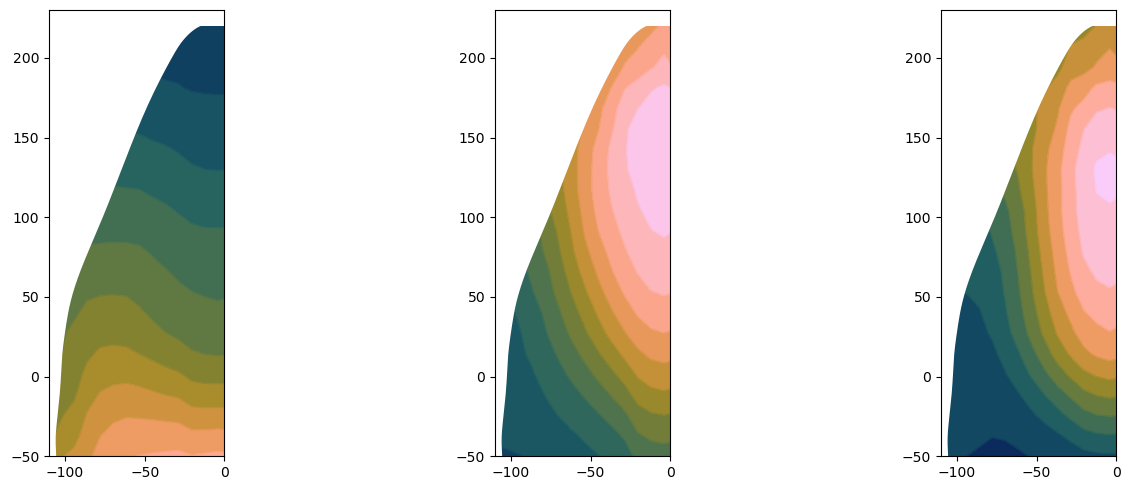

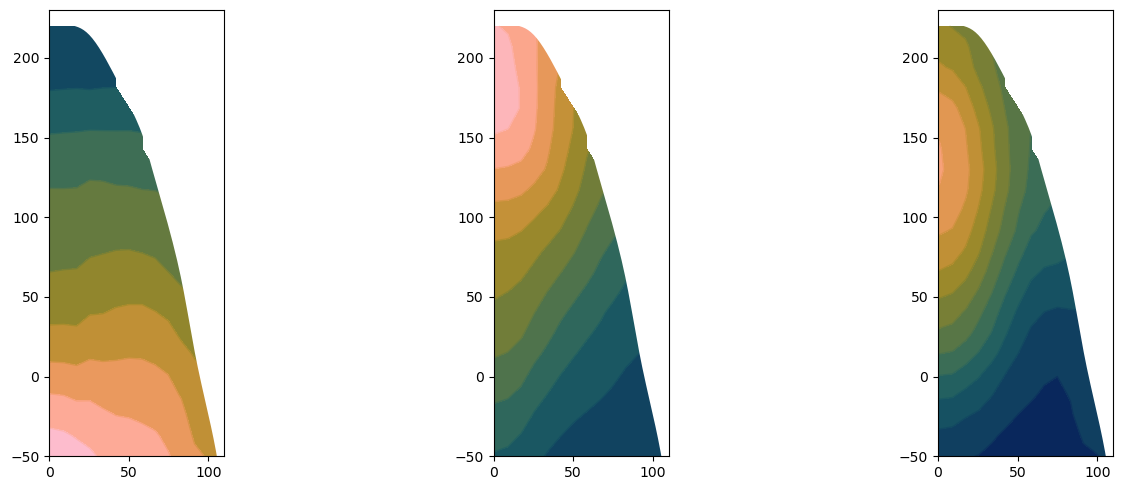

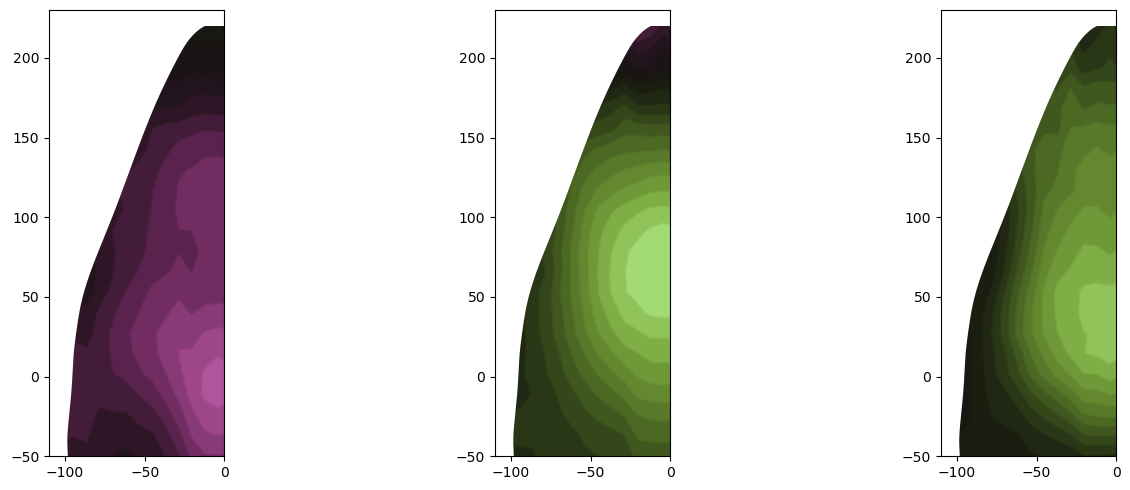

In [ ]:
#Define parameters and GOIs
smooth_size = 3
channels = ['SOX2', 'TBXT', 'TBX6']
xcol = 'Scaled_Rel_LR_position_positive'
ycol = 'Scaled_Rel_AP_position'
n_bins = 30
x_bins = np.linspace(dmso_data[xcol].min(), dmso_data[xcol].max(), n_bins)
y_bins = np.linspace(dmso_data[ycol].min(), dmso_data[ycol].max(), n_bins)
smooth_size = 5
col_lim = (0,0.4)
ylim = (-50,230)
xlim = (-110, 110)
cont_linque_width = 1
outline_line_width=18
smooth_line_scaled=1.05

# Use the plotting functions
DMSO_channel_avg_data, DMSO_averages = process_channel_data(
    dmso_data, 
    xcol, 
    ycol, 
    x_bins, 
    y_bins, 
    channels, 
    smooth_size=smooth_size
)

LY_channel_avg_data, LY_averages = process_channel_data(
    ly_data, 
    xcol, 
    ycol, 
    x_bins, 
    y_bins, 
    channels, 
    smooth_size=smooth_size
)

# Find max per channel to normalise later
max_vals = {}
for channel in channels:
    max_vals[channel] = np.nanmax((np.nanmax(DMSO_channel_avg_data[channel]), 
                                  np.nanmax(LY_channel_avg_data[channel])))

# Create filled contour plots for all channels
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, channel in zip(axes, channels):
    X, Y = np.meshgrid(x_bins[:-1], y_bins[:-1])
    max_val = max_vals[channel]

    CS = ax.contourf(X, Y, DMSO_channel_avg_data[channel].T, cmap=cmc.batlow, levels=12)
    CS.set_clim(0, max_val)

    CS = ax.contour(X, Y, DMSO_channel_avg_data[channel].T, cmap=cmc.batlow, levels=12, linewidths=cont_linque_width)
    CS.set_clim(0, max_val)

    ax.plot(smooth_boundary[0]*smooth_line_scaled-2, smooth_boundary[1], 
            color='white', linewidth=outline_line_width)

    ax.set_aspect('equal')
    ax.set_ylim(ylim)
    ax.set_xlim(-110,0)
    max_val = max_vals[channel]
    # Set color limits
    CS.set_clim(0, max_val)

    # ax.set_ylim(-0.2, 1)
plt.tight_layout()


# Create filled contour plots for all channels
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, channel in zip(axes, channels):
    X, Y = np.meshgrid(x_bins[:-1]+5, y_bins[:-1])
    max_val = max_vals[channel]

    CS = ax.contourf(X, Y, LY_channel_avg_data[channel].T, cmap=cmc.batlow, levels=10)
    CS.set_clim(0, max_val)

    CS = ax.contour(X, Y, LY_channel_avg_data[channel].T, cmap=cmc.batlow, levels=10, linewidths=cont_linque_width)
    CS.set_clim(0, max_val)

    ax.plot(smooth_boundary[0]*smooth_line_scaled+5, smooth_boundary[1], 
            color='white', linewidth=outline_line_width)

    ax.set_ylim(ylim)
    ax.set_xlim(0, 110)
    # Set color limits
    ax.set_aspect('equal')

plt.tight_layout()

# Create filled contour plots for all channels
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, channel in zip(axes, channels):
    X, Y = np.meshgrid(x_bins[:-1], y_bins[:-1])

    #calculate levels so 1 level is around 0.025

    values = DMSO_channel_avg_data[channel].T - LY_channel_avg_data[channel].T
    max_diff = np.abs(np.nanmax(DMSO_channel_avg_data[channel].T - LY_channel_avg_data[channel].T))
    min_p = np.nanmin(DMSO_channel_avg_data[channel].T - LY_channel_avg_data[channel].T)
    max_p = np.nanmax(DMSO_channel_avg_data[channel].T - LY_channel_avg_data[channel].T)
    level_no = int((max_p-min_p) // 0.025)

    CS = ax.contourf(X, Y,values, 
                     cmap=cmc.vanimo, levels=level_no)
    CS.set_clim(-0.35,0.35)

    CS = ax.contour(X, Y,values, 
                    cmap=cmc.vanimo, levels=level_no, linewidths=cont_linque_width)
    
    ax.plot(smooth_boundary[0]*1, smooth_boundary[1], 
            color='white', linewidth=outline_line_width)


    ax.set_ylim(ylim)
    ax.set_xlim(-110,0)
    #set colour limits of max difference
    CS.set_clim(-0.35,0.35)
    # Set color limits

    ax.set_aspect('equal')
plt.tight_layout()

In [ ]:
#Now calculate statistical significance between region means of each output
Cult_Embryo_data['Scaled_Rel_LR_position_positive'] = abs(Cult_Embryo_data['Scaled_Rel_LR_position'].copy())

#Remove right side of embryo 8 (partially out of imaging view)
Cult_Embryo_data_pvals = Cult_Embryo_data[~((Cult_Embryo_data['embryo'] == 8) & (Cult_Embryo_data['Scaled_Rel_LR_position'] > 0))]

n_clusters = int(len(Cult_Embryo_data_pvals)/1500) #number of cells total per cluster /2
Cult_Embryo_data_pvals = Cult_Embryo_data_pvals[~np.isnan(Cult_Embryo_data_pvals['Scaled_Rel_AP_position'])]
Cult_Embryo_data_pvals = Cult_Embryo_data_pvals[~np.isnan(Cult_Embryo_data_pvals['Scaled_Rel_LR_position_positive'])]
Cult_Embryo_data_pvals = Cult_Embryo_data_pvals[(Cult_Embryo_data_pvals['Scaled_Rel_LR_position_positive'])>=0]

#set seed for reproducibility
np.random.seed(0)

#Cluster into groups using KMeans clustering
Cult_Embryo_data_pvals['Scaled_cluster'] = KMeans(n_clusters=n_clusters).fit_predict(Cult_Embryo_data_pvals[['Scaled_Rel_AP_position', 'Scaled_Rel_LR_position_positive']].values)

# Group to summary
cluster_summary = Cult_Embryo_data_pvals.groupby(['Scaled_cluster', 'Condition', 'Replicate']).agg(
    mean_CVSox2=('CV_SOX2', 'mean'),
    mean_CVTbx6=('CV_TBX6', 'mean'),
    mean_CVT=('CV_TBXT', 'mean'),
    mean_NormSox2=('SOX2', 'mean'),
    mean_NormT=('TBXT', 'mean'),
    mean_NormTbx6=('TBX6', 'mean'),
    mean_NbrSox2=('NbrGrd_SOX2', 'mean'),
    mean_NbrTbx6=('NbrGrd_TBX6', 'mean'),
    mean_NbrT=('NbrGrd_TBXT', 'mean')
).reset_index()



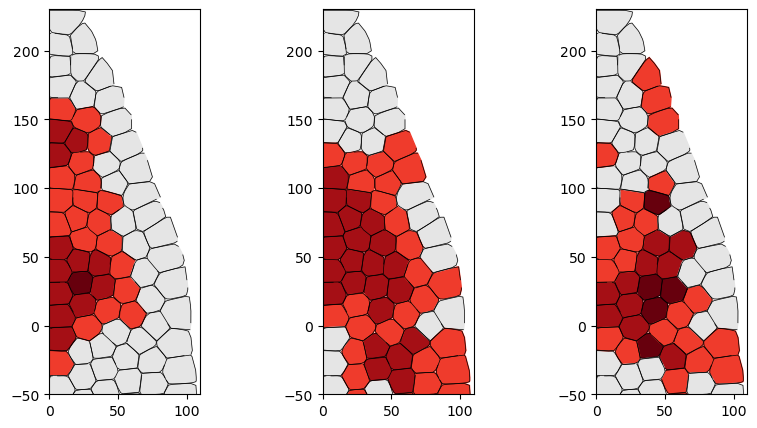

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

for ax, channel in zip(axes, ['mean_NormSox2', 'mean_NormT', 'mean_NormTbx6']):
    for cluster in cluster_summary['Scaled_cluster'].unique():
        
        # Get the data for the current cluster and channel
        cluster_data = cluster_summary[cluster_summary['Scaled_cluster'] == cluster]
        temp = Cult_Embryo_data_pvals[Cult_Embryo_data_pvals['Scaled_cluster'] == cluster]

        #perform t-test for each condition
        dmso = cluster_data[cluster_data['Condition'] == 'DMSO'][channel]
        ly = cluster_data[cluster_data['Condition'] == 'LY'][channel]
        t_stat, p_val = stats.ttest_ind(dmso, ly)

        #assign p-value colour to if >0.05, <0.05, <0.01, <0.001
        if p_val > 0.05:
            p_val_col = '#e5e5e5ff'
        elif p_val < 0.05 and p_val > 0.01:
            p_val_col = '#ef3b2cff'
        elif p_val < 0.01 and p_val > 0.001:
            p_val_col = '#a50f15ff'
        else:
            p_val_col = '#67000dff'

        # Plot the data as a polygon of convex hull and fill it with color
        points = temp[['Scaled_Rel_LR_position_positive', 'Scaled_Rel_AP_position']].values

        if points.shape[0] ==0:
            continue

        # Find the convex hull of the points per cluster
        hull = ConvexHull(points)

        # Plot the convex hull and fill it with the p-value color
        ax.fill(points[hull.vertices, 0], points[hull.vertices, 1],color=p_val_col)
        ax.plot(points[hull.vertices, 0], points[hull.vertices, 1], color='black', linewidth=0.5)
        ax.set_aspect('equal')
        ax.set_ylim(ylim)
        ax.set_xlim(0,110)



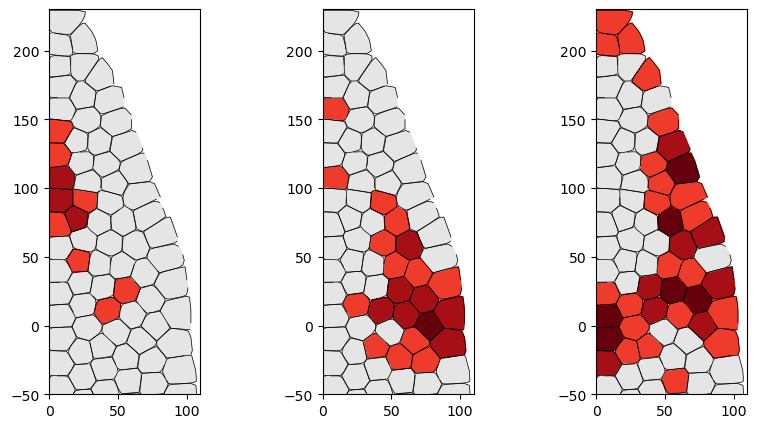

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

for ax, channel in zip(axes, ['mean_CVSox2', 'mean_CVT', 'mean_CVTbx6']):
    for cluster in cluster_summary['Scaled_cluster'].unique():
        # Get the data for the current cluster and channel
        cluster_data = cluster_summary[cluster_summary['Scaled_cluster'] == cluster]
        temp = Cult_Embryo_data_pvals[Cult_Embryo_data_pvals['Scaled_cluster'] == cluster]

        #perform t-test for each condition
        dmso = cluster_data[cluster_data['Condition'] == 'DMSO'][channel]
        ly = cluster_data[cluster_data['Condition'] == 'LY'][channel]
        t_stat, p_val = stats.ttest_ind(dmso, ly)

        #assign p-value colour to if >0.05, <0.05, <0.01, <0.001
        if p_val > 0.05:
            p_val_col = '#e5e5e5ff'
        elif p_val < 0.05 and p_val > 0.01:
            p_val_col = '#ef3b2cff'
        elif p_val < 0.01 and p_val > 0.001:
            p_val_col = '#a50f15ff'
        else:
            p_val_col = '#67000dff'

        # Plot the data as a polygon of convex hull and fill it with color
        points = temp[['Scaled_Rel_LR_position_positive', 'Scaled_Rel_AP_position']].values

        if points.shape[0] ==0:
            continue

        # Find the convex hull of the points per cluster
        hull = ConvexHull(points)

        # Plot the convex hull and fill it with the p-value color
        ax.fill(points[hull.vertices, 0], points[hull.vertices, 1],color=p_val_col)
        ax.plot(points[hull.vertices, 0], points[hull.vertices, 1], color='black', linewidth=0.5)
        ax.set_aspect('equal')
        ax.set_ylim(ylim)
        ax.set_xlim(0,110)



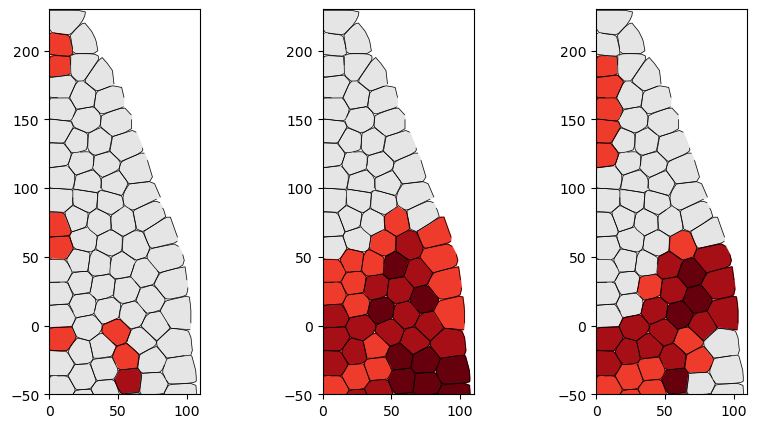

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

for ax, channel in zip(axes, ['mean_NbrSox2', 'mean_NbrT', 'mean_NbrTbx6']):
    for cluster in cluster_summary['Scaled_cluster'].unique():
        # Get the data for the current cluster and channel
        cluster_data = cluster_summary[cluster_summary['Scaled_cluster'] == cluster]
        temp = Cult_Embryo_data_pvals[Cult_Embryo_data_pvals['Scaled_cluster'] == cluster]

        #perform t-test for each condition
        dmso = cluster_data[cluster_data['Condition'] == 'DMSO'][channel]
        ly = cluster_data[cluster_data['Condition'] == 'LY'][channel]
        t_stat, p_val = stats.ttest_ind(dmso, ly)

        #assign p-value colour to if >0.05, <0.05, <0.01, <0.001
        if p_val > 0.05:
            p_val_col = '#e5e5e5ff'
        elif p_val < 0.05 and p_val > 0.01:
            p_val_col = '#ef3b2cff'
        elif p_val < 0.01 and p_val > 0.001:
            p_val_col = '#a50f15ff'
        else:
            p_val_col = '#67000dff'

        # Plot the data as a polygon of convex hull and fill it with color
        points = temp[['Scaled_Rel_LR_position_positive', 'Scaled_Rel_AP_position']].values

        if points.shape[0] ==0:
            continue

        # Find the convex hull of the points per cluster
        hull = ConvexHull(points)

        # Plot the convex hull and fill it with the p-value color
        ax.fill(points[hull.vertices, 0], points[hull.vertices, 1],color=p_val_col)
        ax.plot(points[hull.vertices, 0], points[hull.vertices, 1], color='black', linewidth=0.5)
        ax.set_aspect('equal')
        ax.set_ylim(ylim)
        ax.set_xlim(0,110)

